# Imports

In [8]:
import numpy as np
import pandas as pd
import os
import time
import torch
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from paths import (
    projection_dir,
    projected_emb_path,
    fusion_query_path,
    projection_metrics_path,
    vision_emb_path,
    text_emb_path
)

CURRENT_DATASET = "Flickr8k"

EVAL_DIR = f"TFE_Data/Evaluations/Multimodal/projections/{CURRENT_DATASET}"
os.makedirs(EVAL_DIR, exist_ok=True)


# Load Metadata

In [9]:
# Load raw embeddings (for stress tests)
vision_raw = {
    "ResNet50": np.load(vision_emb_path(CURRENT_DATASET, "ResNet50")),
    "ViT":      np.load(vision_emb_path(CURRENT_DATASET, "ViT")),
    "MobileNetV3": np.load(vision_emb_path(CURRENT_DATASET, "MobileNetV3")),
    "PVT": np.load(vision_emb_path(CURRENT_DATASET, "PVT")),
}

text_raw = {
    "BERT":    np.load(text_emb_path(CURRENT_DATASET, "BERT")),
    "RoBERTa": np.load(text_emb_path(CURRENT_DATASET, "RoBERTa")),
    "GPT2":    np.load(text_emb_path(CURRENT_DATASET, "GPT2")),
}

# Load Flickr8k captions
df_text = pd.read_pickle("TFE_Data/Datasets/df_Flickr8k.pkl")

images = df_text["image_name"].tolist()
captions = [cap for row in df_text["captions"] for cap in row]
image_to_idx = {img: i for i, img in enumerate(images)}


# Retrieve

In [10]:
def topk_cosine_batch(Q, I, k=50, batch=256):
    k = min(k, I.shape[0])   # <-- FIX: cannot request more than available

    Qn = Q / np.linalg.norm(Q, axis=1, keepdims=True)
    In = I / np.linalg.norm(I, axis=1, keepdims=True)

    Nq = len(Q)
    topk = np.zeros((Nq, k), dtype=np.int32)

    for start in range(0, Nq, batch):
        end = start + batch
        sim = Qn[start:end] @ In.T
        topk[start:end] = np.argpartition(-sim, k-1, axis=1)[:, :k]

    return topk

def retrieval_metrics_from_topk(topk, gt):
    ranks = []
    for i in range(len(gt)):
        hits = np.where(topk[i] == gt[i])[0]
        ranks.append(hits[0] if len(hits) else topk.shape[1])

    ranks = np.array(ranks)
    return {
        "R@1":  np.mean(ranks < 1),
        "R@5":  np.mean(ranks < 5),
        "R@10": np.mean(ranks < 10),
        "MedR": np.median(ranks) + 1,
        "MeanR": np.mean(ranks) + 1
    }


def benchmark_retrieval(Q, I, n_runs=5):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()

    latencies = []
    for _ in range(n_runs):
        t0 = time.time()
        _ = Q @ I.T
        torch.cuda.synchronize()
        latencies.append(time.time() - t0)

    avg = np.mean(latencies)
    return {
        "latency": avg,
        "per_sample": avg / len(Q),
        "throughput": len(Q) / avg,
        "gpu_mem": torch.cuda.max_memory_allocated() / (1024**2)
    }


In [11]:
def evaluate_image_to_text(Xv_proj, Xt_proj, dataset, v, t, method):
    out_dir = projection_dir(dataset, v, t, method)
    os.makedirs(out_dir, exist_ok=True)

    top50 = topk_cosine_batch(Xv_proj, Xt_proj, k=50)
    np.save(f"{out_dir}/i2t_top50.npy", top50)

    gt = [i * 5 for i in range(len(Xv_proj))]
    return retrieval_metrics_from_topk(top50, gt)


def evaluate_text_to_image(Xv_proj, Xt_proj, dataset, v, t, method):
    out_dir = projection_dir(dataset, v, t, method)
    os.makedirs(out_dir, exist_ok=True)

    top50 = topk_cosine_batch(Xt_proj, Xv_proj, k=50)
    np.save(f"{out_dir}/t2i_top50.npy", top50)

    gt = [j // 5 for j in range(len(Xt_proj))]
    return retrieval_metrics_from_topk(top50, gt)


def evaluate_multimodal_to_text(F_multi, Xt_proj, dataset, v, t, method, fusion):
    out_dir = projection_dir(dataset, v, t, method)
    os.makedirs(out_dir, exist_ok=True)

    top50 = topk_cosine_batch(F_multi, Xt_proj, k=50)
    np.save(f"{out_dir}/{fusion}_m2t_top50.npy", top50)

    gt = [i * 5 for i in range(len(F_multi))]
    return retrieval_metrics_from_topk(top50, gt)


def evaluate_multimodal_to_image(F_multi, Xv_proj, dataset, v, t, method, fusion):
    out_dir = projection_dir(dataset, v, t, method)
    os.makedirs(out_dir, exist_ok=True)

    top50 = topk_cosine_batch(F_multi, Xv_proj, k=50)
    np.save(f"{out_dir}/{fusion}_m2i_top50.npy", top50)

    gt = list(range(len(F_multi)))
    return retrieval_metrics_from_topk(top50, gt)


In [12]:
IMAGE_DIR = f"TFE_Data/Datasets/{CURRENT_DATASET}/Images"

STRESS_TEST_IMAGES = [
    "107582366_d86f2d3347.jpg",
    "127450902_533ceeddfc.jpg",
    "112178718_87270d9b4d.jpg",
    "141755290_4b954529f3.jpg",
    "171488318_fb26af58e2.jpg",
    "240583223_e26e17ee96.jpg",
    "241346317_be3f07bd2e.jpg",
    "911795495_342bb15b97.jpg",
    "2452686995_621878f561.jpg",
    "97577988_65e2eae14a.jpg"
]

df_text = pd.read_pickle("TFE_Data/Datasets/df_Flickr8k.pkl")

images = df_text["image_name"].tolist()
captions = [cap for row in df_text["captions"] for cap in row]

image_to_idx = {img: i for i, img in enumerate(images)}

STRESS_IMAGE_INDEXES = []
STRESS_TEXT_INDEXES = []
STRESS_TEXTS = []

for fname in STRESS_TEST_IMAGES:
    idx = image_to_idx[fname]
    cap_idx = idx * 5

    STRESS_IMAGE_INDEXES.append(idx)
    STRESS_TEXT_INDEXES.append(cap_idx)
    STRESS_TEXTS.append(captions[cap_idx])


def get_stress_raw_embeddings(v_name, t_name):
    raw_imgs = vision_raw[v_name][STRESS_IMAGE_INDEXES]
    raw_txts = text_raw[t_name][STRESS_TEXT_INDEXES]
    return raw_imgs, raw_txts


In [16]:
USE_STRESS = False

In [17]:
results = []

df_align = pd.read_csv(projection_metrics_path(CURRENT_DATASET))

for _, row in df_align.iterrows():
    v = row["vision"]
    t = row["text"]
    method = row["method"]

    print(f"Evaluating {v} × {t} — {method}")

    Xv_proj = np.load(projected_emb_path(CURRENT_DATASET, v, t, method, "Xv"))
    Xt_proj = np.load(projected_emb_path(CURRENT_DATASET, v, t, method, "Xt"))
    
    if USE_STRESS:
        Xv_proj = Xv_proj[STRESS_IMAGE_INDEXES]
        Xt_proj = Xt_proj[STRESS_TEXT_INDEXES]
    else:
        Xv_proj = Xv_proj
        Xt_proj = Xt_proj

    r_i2t = evaluate_image_to_text(Xv_proj, Xt_proj, CURRENT_DATASET, v, t, method)
    r_t2i = evaluate_text_to_image(Xv_proj, Xt_proj, CURRENT_DATASET, v, t, method)

    eff_i2t = benchmark_retrieval(Xv_proj, Xt_proj)
    eff_t2i = benchmark_retrieval(Xt_proj, Xv_proj)

    for fusion in ["add", "gated", "mul"]:
        F = np.load(fusion_query_path(CURRENT_DATASET, v, t, method, fusion))

        r_m2t = evaluate_multimodal_to_text(F, Xt_proj, CURRENT_DATASET, v, t, method, fusion)
        r_m2i = evaluate_multimodal_to_image(F, Xv_proj, CURRENT_DATASET, v, t, method, fusion)

        eff_m2t = benchmark_retrieval(F, Xt_proj)
        eff_m2i = benchmark_retrieval(F, Xv_proj)

        results.append({
            "vision": v,
            "text": t,
            "method": method,
            "fusion": fusion,
            **{f"i2t_{k}": v for k, v in r_i2t.items()},
            **{f"t2i_{k}": v for k, v in r_t2i.items()},
            **{f"m2t_{k}": v for k, v in r_m2t.items()},
            **{f"m2i_{k}": v for k, v in r_m2i.items()},
            **{f"eff_i2t_{k}": v for k, v in eff_i2t.items()},
            **{f"eff_t2i_{k}": v for k, v in eff_t2i.items()},
            **{f"eff_m2t_{k}": v for k, v in eff_m2t.items()},
            **{f"eff_m2i_{k}": v for k, v in eff_m2i.items()},
        })


Evaluating ResNet50 × BERT — RP
Evaluating ResNet50 × BERT — WCCA
Evaluating ResNet50 × BERT — CPCA
Evaluating ResNet50 × RoBERTa — RP
Evaluating ResNet50 × RoBERTa — WCCA
Evaluating ResNet50 × RoBERTa — CPCA
Evaluating ResNet50 × GPT-2 — RP
Evaluating ResNet50 × GPT-2 — WCCA
Evaluating ResNet50 × GPT-2 — CPCA
Evaluating ViT × BERT — RP
Evaluating ViT × BERT — WCCA
Evaluating ViT × BERT — CPCA
Evaluating ViT × RoBERTa — RP
Evaluating ViT × RoBERTa — WCCA
Evaluating ViT × RoBERTa — CPCA
Evaluating ViT × GPT-2 — RP
Evaluating ViT × GPT-2 — WCCA
Evaluating ViT × GPT-2 — CPCA
Evaluating MobileNetV3 × BERT — RP
Evaluating MobileNetV3 × BERT — WCCA
Evaluating MobileNetV3 × BERT — CPCA
Evaluating MobileNetV3 × RoBERTa — RP
Evaluating MobileNetV3 × RoBERTa — WCCA
Evaluating MobileNetV3 × RoBERTa — CPCA
Evaluating MobileNetV3 × GPT-2 — RP
Evaluating MobileNetV3 × GPT-2 — WCCA
Evaluating MobileNetV3 × GPT-2 — CPCA
Evaluating PVT × BERT — RP
Evaluating PVT × BERT — WCCA
Evaluating PVT × BERT — CP

In [18]:
df = pd.DataFrame(results)
df.to_csv(f"{EVAL_DIR}/retrieval_results.csv", index=False)
df


,vision,text,method,fusion,i2t_R@1,i2t_R@5,i2t_R@10,i2t_MedR,i2t_MeanR,t2i_R@1,...,eff_t2i_throughput,eff_t2i_gpu_mem,eff_m2t_latency,eff_m2t_per_sample,eff_m2t_throughput,eff_m2t_gpu_mem,eff_m2i_latency,eff_m2i_per_sample,eff_m2i_throughput,eff_m2i_gpu_mem
0,ResNet50,BERT,RP,add,0.000000,0.000000,0.000000,51.0,50.968607,0.000124,...,19964.785982,0.0,10.378731,0.000257,3897.875336,0.0,2.093695,0.000052,19322.302385,0.0
1,ResNet50,BERT,RP,gated,0.000000,0.000000,0.000000,51.0,50.968607,0.000124,...,19964.785982,0.0,10.273780,0.000254,3937.693741,0.0,2.088521,0.000052,19370.162278,0.0
2,ResNet50,BERT,RP,mul,0.000000,0.000000,0.000000,51.0,50.968607,0.000124,...,19964.785982,0.0,10.001609,0.000247,4044.849014,0.0,2.050827,0.000051,19726.188713,0.0
3,ResNet50,BERT,WCCA,add,0.005562,0.029168,0.062168,51.0,43.910518,0.004474,...,39641.576754,0.0,5.027161,0.000124,8047.285952,0.0,0.997184,0.000025,40569.225916,0.0
4,ResNet50,BERT,WCCA,gated,0.005562,0.029168,0.062168,51.0,43.910518,0.004474,...,39641.576754,0.0,4.961388,0.000123,8153.968178,0.0,1.018529,0.000025,39719.063083,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,PVT,GPT-2,WCCA,gated,0.000742,0.003584,0.009022,51.0,49.829069,0.000025,...,38793.640772,0.0,4.912193,0.000121,8235.629957,0.0,1.047050,0.000026,38637.137451,0.0
104,PVT,GPT-2,WCCA,mul,0.000742,0.003584,0.009022,51.0,49.829069,0.000025,...,38793.640772,0.0,4.885731,0.000121,8280.235670,0.0,1.028229,0.000025,39344.339336,0.0
105,PVT,GPT-2,CPCA,add,0.000494,0.003213,0.005809,51.0,50.311334,0.000198,...,39634.520935,0.0,5.113685,0.000126,7911.124259,0.0,1.076275,0.000027,37587.963208,0.0
106,PVT,GPT-2,CPCA,gated,0.000494,0.003213,0.005809,51.0,50.311334,0.000198,...,39634.520935,0.0,5.094800,0.000126,7940.449687,0.0,1.053739,0.000026,38391.872897,0.0


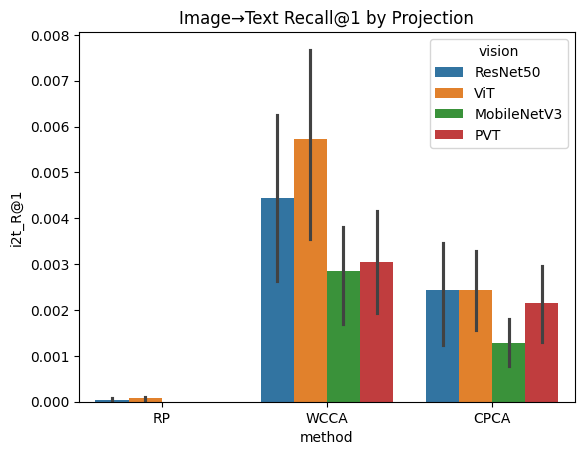

In [19]:
sns.barplot(data=df, x="method", y="i2t_R@1", hue="vision")
plt.title("Image→Text Recall@1 by Projection")
plt.show()


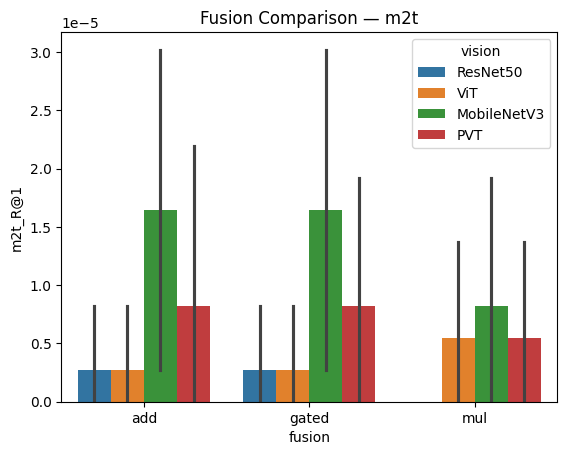

In [20]:
sns.barplot(data=df, x="fusion", y="m2t_R@1", hue="vision")
plt.title("Fusion Comparison — m2t")
plt.show()


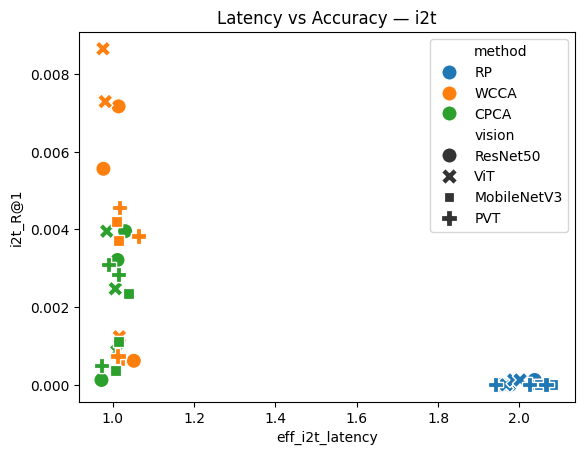

In [21]:
sns.scatterplot(
    data=df,
    x="eff_i2t_latency",
    y="i2t_R@1",
    hue="method",
    style="vision",
    s=120
)
plt.title("Latency vs Accuracy — i2t")
plt.show()


In [22]:
from PIL import Image

def visualize_example(img_idx, v, t, method, fusion):
    print(f"Example for {v} × {t} — {method} — fusion={fusion}")

    img_name = images[img_idx]
    img_path = f"TFE_Data/Flickr8k/Images/Flicker8k_Dataset/{img_name}"
    plt.imshow(Image.open(img_path))
    plt.axis("off")
    plt.show()

    out_dir = projection_dir(CURRENT_DATASET, v, t, method)

    i2t = np.load(f"{out_dir}/i2t_top50.npy")
    t2i = np.load(f"{out_dir}/t2i_top50.npy")
    m2t = np.load(f"{out_dir}/{fusion}_m2t_top50.npy")
    m2i = np.load(f"{out_dir}/{fusion}_m2i_top50.npy")

    print("Top captions (i2t):")
    for idx in i2t[img_idx][:5]:
        print("-", captions[idx])


# Execution

In [ ]:

STRESS_TEST_IMAGES = [
    os.path.join(IMAGE_DIR, fname)
    for fname in [
        "107582366_d86f2d3347.jpg",
        "127450902_533ceeddfc.jpg",
        "112178718_87270d9b4d.jpg",
        "141755290_4b954529f3.jpg",
        "171488318_fb26af58e2.jpg",
        "240583223_e26e17ee96.jpg",
        "241346317_be3f07bd2e.jpg",
        "911795495_342bb15b97.jpg",
        "2452686995_621878f561.jpg",
        "97577988_65e2eae14a.jpg"
    ]
]

# Load Flickr8k captions
df_text = pd.read_pickle("TFE_Data/Datasets/df_Flickr8k.pkl")

captions = []
caption_image_map = []

for _, row in df_text.iterrows():
    img = row["image_name"]
    for cap in row["captions"]:
        captions.append(cap)
        caption_image_map.append(img)

images = df_text["image_name"].tolist()

image_to_idx = {img: idx for idx, img in enumerate(images)}
caption_to_image_idx = [image_to_idx[img] for img in caption_image_map]


# 3. Index of images (for evaluation)
index_to_image = images

STRESS_IMAGE_INDEXES = []
STRESS_TEXT_INDEXES = []
STRESS_TEXTS = []

for full_path in STRESS_TEST_IMAGES:
    fname = os.path.basename(full_path)   # <-- FIX: strip directory
    idx = image_to_idx[fname]             # now it matches the dict keys

    # Each image has 5 captions stored sequentially
    cap_idx = idx * 5

    STRESS_IMAGE_INDEXES.append(idx)
    STRESS_TEXT_INDEXES.append(cap_idx)
    STRESS_TEXTS.append(captions[cap_idx])



os.makedirs("UP_retrieval_Projection_results_all", exist_ok=True)

df_align = pd.read_csv("UP_alignment_metrics_all/alignment_results.csv")

def get_stress_raw_embeddings(v_name, t_name):
    raw_imgs = vision_raw[v_name][STRESS_IMAGE_INDEXES]
    raw_txts = text_raw[t_name][STRESS_TEXT_INDEXES]
    return raw_imgs, raw_txts


In [ ]:
def reduce_to_latent(F_raw, latent_dim=128):
    D = F_raw.shape[1]
    W = np.random.randn(D, latent_dim) / np.sqrt(D)
    return F_raw @ W


In [ ]:
def retrieval_metrics_from_topk(topk, gt):
    """
    topk: (Nq, K) array of top‑K retrieved indices
    gt:   list of ground‑truth indices (len Nq)

    Returns standard retrieval metrics.
    """
    ranks = []

    for i in range(len(gt)):
        # Find where the ground‑truth index appears in the top‑K list
        hits = np.where(topk[i] == gt[i])[0]

        if len(hits) == 0:
            # Not in top‑K → rank = K (worst possible)
            ranks.append(topk.shape[1])
        else:
            ranks.append(hits[0])

    ranks = np.array(ranks)

    return {
        "R@1":  np.mean(ranks < 1),
        "R@5":  np.mean(ranks < 5),
        "R@10": np.mean(ranks < 10),
        "MedR": np.median(ranks) + 1,
        "MeanR": np.mean(ranks) + 1
    }


In [ ]:

LATENT_DIM = 128
Fusion_methods = ["Addition", "Gated", "Multiplication"]

retrieval_results = []

for _, row in df_align.iterrows():

    v = row["Vision_Model"]
    t = row["Text_Model"]
    proj = row["Projection"]
    
    print(f"Evaluating retrieval for {v} × {t} — {proj}")

    # Load projected embeddings
    Xv_proj = np.load(f"UP_projected_embeddings_all/{v}_{t}_{proj}_Xv.npy")   # (8091, d)
    Xt_proj = np.load(f"UP_projected_embeddings_all/{v}_{t}_{proj}_Xt.npy")   # (40455, d)

    # NO REORDERING — Xt_proj is already correct

    # Unimodal retrieval
    r_i2t = evaluate_image_to_text(Xv_proj, Xt_proj, v, t, proj)
    r_t2i = evaluate_text_to_image(Xv_proj, Xt_proj, v, t, proj)

    # Efficiency
    Efficiency_i2t = benchmark_retrieval(Xv_proj, Xt_proj)
    Efficiency_t2i = benchmark_retrieval(Xt_proj, Xv_proj)


    for Fusion in Fusion_methods:
        F_multi = np.load(f"UP_Fusion_queries_all/{v}_{t}_{proj}_CAP_{Fusion}.npy")

        r_m2t = evaluate_multimodal_to_text(F_multi, Xt_proj, v, t, proj, Fusion)
        r_m2i = evaluate_multimodal_to_image(F_multi, Xv_proj, v, t, proj, Fusion)

        # Efficiency
        Efficiency_m2t = benchmark_retrieval(F_multi, Xt_proj)
        Efficiency_m2i = benchmark_retrieval(F_multi, Xv_proj)

        retrieval_results.append({
            "Vision_Model": v,
            "Text_Model": t,
            "Projection": proj,
            "Fusion": Fusion,
            "i2t": r_i2t,
            "t2i": r_t2i,
            "m2t": r_m2t,
            "m2i": r_m2i,
            "Efficiency_i2t": Efficiency_i2t,
            "Efficiency_t2i": Efficiency_t2i,
            "Efficiency_m2t": Efficiency_m2t,
            "Efficiency_m2i": Efficiency_m2i
        })


Evaluating retrieval for MobileNetV3 × RoBERTa — RP
Evaluating retrieval for MobileNetV3 × RoBERTa — WCCA
Evaluating retrieval for MobileNetV3 × RoBERTa — CPCA
Evaluating retrieval for MobileNetV3 × BERT — RP
Evaluating retrieval for MobileNetV3 × BERT — WCCA
Evaluating retrieval for MobileNetV3 × BERT — CPCA
Evaluating retrieval for MobileNetV3 × GPT2 — RP
Evaluating retrieval for MobileNetV3 × GPT2 — WCCA
Evaluating retrieval for MobileNetV3 × GPT2 — CPCA
Evaluating retrieval for PVT × RoBERTa — RP
Evaluating retrieval for PVT × RoBERTa — WCCA
Evaluating retrieval for PVT × RoBERTa — CPCA
Evaluating retrieval for PVT × BERT — RP
Evaluating retrieval for PVT × BERT — WCCA
Evaluating retrieval for PVT × BERT — CPCA
Evaluating retrieval for PVT × GPT2 — RP
Evaluating retrieval for PVT × GPT2 — WCCA
Evaluating retrieval for PVT × GPT2 — CPCA
Evaluating retrieval for ResNet50 × RoBERTa — RP
Evaluating retrieval for ResNet50 × RoBERTa — WCCA
Evaluating retrieval for ResNet50 × RoBERTa — CP

In [ ]:
# Convert list of dicts to DataFrame
df_results = pd.DataFrame(retrieval_results)
df = pd.json_normalize(retrieval_results)

df.columns = (
    df.columns
    .str.replace("i2t.", "i2t_", regex=False)
    .str.replace("t2i.", "t2i_", regex=False)
    .str.replace("m2t.", "m2t_", regex=False)
    .str.replace("m2i.", "m2i_", regex=False)
    .str.replace("Efficiency_i2t.", "Efficiency_i2t_", regex=False)
    .str.replace("Efficiency_t2i.", "Efficiency_t2i_", regex=False)
    .str.replace("Efficiency_m2t.", "Efficiency_m2t_", regex=False)
    .str.replace("Efficiency_m2i.", "Efficiency_m2i_", regex=False)
)

# Sauvegarde en CSV
df.to_csv("UP_retrieval_results_all/retrieval_results_all.csv", index=False)

print("✔ CSV saved at UP_retrieval_results_all/retrieval_results_all.csv")


NameError: name 'retrieval_results' is not defined

In [ ]:
df = pd.read_csv("UP_retrieval_results_all/retrieval_results_all.csv")

df.head()

,Vision_Model,Text_Model,Projection,Fusion,i2t_R@1,i2t_R@5,i2t_R@10,i2t_MedR,i2t_MeanR,t2i_R@1,...,Efficiency_t2i_throughput,Efficiency_t2i_gpu_mem,Efficiency_m2t_latency,Efficiency_m2t_per_sample,Efficiency_m2t_throughput,Efficiency_m2t_gpu_mem,Efficiency_m2i_latency,Efficiency_m2i_per_sample,Efficiency_m2i_throughput,Efficiency_m2i_gpu_mem
0,MobileNetV3,RoBERTa,RP,Addition,0.000124,0.000247,0.000247,51.0,50.961191,0.00000,...,19972.210415,0.0,8.170813,0.000202,4951.159673,0.0,1.644062,0.000041,24606.731328,0.0
1,MobileNetV3,RoBERTa,RP,Gated,0.000124,0.000247,0.000247,51.0,50.961191,0.00000,...,19972.210415,0.0,9.694016,0.000240,4173.193018,0.0,2.030971,0.000050,19919.046430,0.0
2,MobileNetV3,RoBERTa,RP,Multiplication,0.000124,0.000247,0.000247,51.0,50.961191,0.00000,...,19972.210415,0.0,9.754050,0.000241,4147.507809,0.0,2.001458,0.000049,20212.768013,0.0
3,MobileNetV3,RoBERTa,WCCA,Addition,0.004449,0.024224,0.048943,51.0,45.100729,0.00042,...,41711.130035,0.0,4.807964,0.000119,8414.164014,0.0,0.956732,0.000024,42284.562972,0.0
4,MobileNetV3,RoBERTa,WCCA,Gated,0.004449,0.024224,0.048943,51.0,45.100729,0.00042,...,41711.130035,0.0,4.890291,0.000121,8272.513724,0.0,0.973224,0.000024,41568.038852,0.0


In [ ]:
cols = ["Vision_Model", "Text_Model", "Projection", "Fusion"] + [c for c in df.columns if "m2" in c]
df[cols]

,Vision_Model,Text_Model,Projection,Fusion,m2t_R@1,m2t_R@5,m2t_R@10,m2t_MedR,m2t_MeanR,m2i_R@1,...,m2i_MedR,m2i_MeanR,Efficiency_m2t_latency,Efficiency_m2t_per_sample,Efficiency_m2t_throughput,Efficiency_m2t_gpu_mem,Efficiency_m2i_latency,Efficiency_m2i_per_sample,Efficiency_m2i_throughput,Efficiency_m2i_gpu_mem
0,MobileNetV3,RoBERTa,RP,Addition,0.000000,0.000074,0.000124,51.0,50.989495,0.000099,...,51.0,50.955679,8.170813,0.000202,4951.159673,0.0,1.644062,0.000041,24606.731328,0.0
1,MobileNetV3,RoBERTa,RP,Gated,0.000000,0.000074,0.000124,51.0,50.989495,0.000099,...,51.0,50.955679,9.694016,0.000240,4173.193018,0.0,2.030971,0.000050,19919.046430,0.0
2,MobileNetV3,RoBERTa,RP,Multiplication,0.000025,0.000025,0.000049,51.0,50.994389,0.000049,...,51.0,50.964479,9.754050,0.000241,4147.507809,0.0,2.001458,0.000049,20212.768013,0.0
3,MobileNetV3,RoBERTa,WCCA,Addition,0.000000,0.000000,0.000025,51.0,50.992757,0.000000,...,51.0,50.962773,4.807964,0.000119,8414.164014,0.0,0.956732,0.000024,42284.562972,0.0
4,MobileNetV3,RoBERTa,WCCA,Gated,0.000000,0.000000,0.000025,51.0,50.992757,0.000000,...,51.0,50.962773,4.890291,0.000121,8272.513724,0.0,0.973224,0.000024,41568.038852,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,ViT,GPT2,WCCA,Gated,0.000025,0.000049,0.000049,51.0,50.992238,0.000025,...,51.0,50.964973,4.907633,0.000121,8243.282045,0.0,0.973169,0.000024,41570.354655,0.0
104,ViT,GPT2,WCCA,Multiplication,0.000025,0.000049,0.000074,51.0,50.992930,0.000000,...,51.0,50.968657,4.797616,0.000119,8432.312956,0.0,1.088219,0.000027,37175.415827,0.0
105,ViT,GPT2,CPCA,Addition,0.000000,0.000025,0.000074,51.0,50.991769,0.000000,...,51.0,50.969472,4.763126,0.000118,8493.372485,0.0,0.935428,0.000023,43247.589562,0.0
106,ViT,GPT2,CPCA,Gated,0.000000,0.000025,0.000074,51.0,50.991769,0.000000,...,51.0,50.969472,4.894572,0.000121,8265.278320,0.0,0.966443,0.000024,41859.701375,0.0


In [ ]:
# Best Projection_matrices
df.groupby("Projection")[["i2t_R@1", "t2i_R@1", "m2t_R@1", "m2i_R@1"]].mean()
print(df.groupby("Projection")[["i2t_R@1", "t2i_R@1", "m2t_R@1", "m2i_R@1"]].mean())

# best Fusion
df.groupby("Fusion")[["m2t_R@1", "m2i_R@1"]].mean()
print(df.groupby("Fusion")[["m2t_R@1", "m2i_R@1"]].mean())

# best Fusion v and t
df.groupby(["Vision_Model", "Text_Model"])[["m2t_R@1", "m2i_R@1"]].mean()
print(df.groupby(["Vision_Model", "Text_Model"])[["m2t_R@1", "m2i_R@1"]].mean())

# global best
df["Global_Score"] = (df["i2t_R@1"] + df["t2i_R@1"] + df["m2t_R@1"] + df["m2i_R@1"]) / 4
df.sort_values("Global_Score", ascending=False)

# efficient best
df["Efficiency_Score"] = df["Global_Score"] / (
    df["Efficiency_i2t_latency"] + df["Efficiency_t2i_latency"] + df["Efficiency_m2t_latency"] + df["Efficiency_m2i_latency"]
)
df.sort_values("Efficiency_Score", ascending=False)


             i2t_R@1   t2i_R@1   m2t_R@1   m2i_R@1
Projection                                        
CPCA        0.002060  0.001434  0.000003  0.000031
RP          0.000051  0.000103  0.000003  0.000032
WCCA        0.004357  0.001609  0.000007  0.000022
                 m2t_R@1   m2i_R@1
Fusion                            
Addition        0.000004  0.000031
Gated           0.000004  0.000031
Multiplication  0.000005  0.000023
                          m2t_R@1   m2i_R@1
Vision_Model Text_Model                    
MobileNetV3  BERT        0.000005  0.000038
             GPT2        0.000005  0.000025
             RoBERTa     0.000003  0.000044
PVT          BERT        0.000003  0.000025
             GPT2        0.000008  0.000030
             RoBERTa     0.000000  0.000014
ResNet50     BERT        0.000000  0.000041
             GPT2        0.000011  0.000025
             RoBERTa     0.000005  0.000025
ViT          BERT        0.000003  0.000025
             GPT2        0.000008  0.00001

,Vision_Model,Text_Model,Projection,Fusion,i2t_R@1,i2t_R@5,i2t_R@10,i2t_MedR,i2t_MeanR,t2i_R@1,...,Efficiency_m2t_latency,Efficiency_m2t_per_sample,Efficiency_m2t_throughput,Efficiency_m2t_gpu_mem,Efficiency_m2i_latency,Efficiency_m2i_per_sample,Efficiency_m2i_throughput,Efficiency_m2i_gpu_mem,Global_Score,Efficiency_Score
94,ViT,BERT,WCCA,Gated,0.007416,0.036584,0.073168,51.0,42.529724,0.006254,...,4.796463,0.000119,8434.339277,0.0,0.939707,0.000023,43050.657708,0.0,0.003417,4.464090e-04
95,ViT,BERT,WCCA,Multiplication,0.007416,0.036584,0.073168,51.0,42.529724,0.006254,...,4.830673,0.000119,8374.608792,0.0,0.960244,0.000024,42129.923781,0.0,0.003417,4.432392e-04
93,ViT,BERT,WCCA,Addition,0.007416,0.036584,0.073168,51.0,42.529724,0.006254,...,4.881954,0.000121,8286.641122,0.0,1.018938,0.000025,39703.113132,0.0,0.003417,4.370058e-04
66,ResNet50,BERT,WCCA,Addition,0.006056,0.033000,0.063033,51.0,43.869855,0.004647,...,4.968108,0.000123,8142.939725,0.0,0.967978,0.000024,41793.311368,0.0,0.002682,3.389223e-04
67,ResNet50,BERT,WCCA,Gated,0.006056,0.033000,0.063033,51.0,43.869855,0.004647,...,4.974564,0.000123,8132.371420,0.0,0.979862,0.000024,41286.425104,0.0,0.002682,3.381386e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,ResNet50,GPT2,RP,Addition,0.000000,0.000124,0.000247,51.0,50.985169,0.000074,...,9.904264,0.000245,4084.604261,0.0,1.996577,0.000049,20262.180890,0.0,0.000019,1.160064e-06
73,ResNet50,GPT2,RP,Gated,0.000000,0.000124,0.000247,51.0,50.985169,0.000074,...,10.038454,0.000248,4030.002832,0.0,2.069694,0.000051,19546.368676,0.0,0.000019,1.145209e-06
36,PVT,BERT,RP,Addition,0.000000,0.000000,0.000124,51.0,50.982697,0.000025,...,9.511595,0.000235,4253.229677,0.0,2.162403,0.000053,18708.353938,0.0,0.000012,7.810617e-07
37,PVT,BERT,RP,Gated,0.000000,0.000000,0.000124,51.0,50.982697,0.000025,...,9.836112,0.000243,4112.905677,0.0,1.936022,0.000048,20895.940280,0.0,0.000012,7.762476e-07


In [ ]:
import json 

df.to_json("retrieval_results.json", orient = "records", indent = 4)

# Normalize nested dicts into flat columns
df = pd.json_normalize(json.load(open("retrieval_results.json")))
df.columns = (
    df.columns
    .str.replace("i2t.", "i2t_", regex=False)
    .str.replace("t2i.", "t2i_", regex=False)
    .str.replace("m2t.", "m2t_", regex=False)
    .str.replace("m2i.", "m2i_", regex=False)
    .str.replace("Efficiency_i2t.", "Efficiency_i2t_", regex=False)
    .str.replace("Efficiency_t2i.", "Efficiency_t2i_", regex=False)
    .str.replace("Efficiency_m2t.", "Efficiency_m2t_", regex=False)
    .str.replace("Efficiency_m2i.", "Efficiency_m2i_", regex=False)
)


df.head()



,Vision_Model,Text_Model,Projection,Fusion,i2t_R@1,i2t_R@5,i2t_R@10,i2t_MedR,i2t_MeanR,t2i_R@1,...,Efficiency_m2t_latency,Efficiency_m2t_per_sample,Efficiency_m2t_throughput,Efficiency_m2t_gpu_mem,Efficiency_m2i_latency,Efficiency_m2i_per_sample,Efficiency_m2i_throughput,Efficiency_m2i_gpu_mem,Global_Score,Efficiency_Score
0,MobileNetV3,RoBERTa,RP,Addition,0.000124,0.000247,0.000247,51.0,50.961191,0.00000,...,8.170813,0.000202,4951.159673,0.0,1.644062,0.000041,24606.731328,0.0,0.000056,0.000004
1,MobileNetV3,RoBERTa,RP,Gated,0.000124,0.000247,0.000247,51.0,50.961191,0.00000,...,9.694016,0.000240,4173.193018,0.0,2.030971,0.000050,19919.046430,0.0,0.000056,0.000004
2,MobileNetV3,RoBERTa,RP,Multiplication,0.000124,0.000247,0.000247,51.0,50.961191,0.00000,...,9.754050,0.000241,4147.507809,0.0,2.001458,0.000049,20212.768013,0.0,0.000049,0.000003
3,MobileNetV3,RoBERTa,WCCA,Addition,0.004449,0.024224,0.048943,51.0,45.100729,0.00042,...,4.807964,0.000119,8414.164014,0.0,0.956732,0.000024,42284.562972,0.0,0.001217,0.000159
4,MobileNetV3,RoBERTa,WCCA,Gated,0.004449,0.024224,0.048943,51.0,45.100729,0.00042,...,4.890291,0.000121,8272.513724,0.0,0.973224,0.000024,41568.038852,0.0,0.001217,0.000157


In [ ]:
df["Global_Score"] = (
    df["i2t_R@1"] * 0.5 +
    df["t2i_R@1"] * 0.5
)
df["Efficiency_Score"] = (
    df["Global_Score"] / (df["Efficiency_i2t_latency"] + df["Efficiency_t2i_latency"])
)


In [ ]:
df.sort_values("Global_Score", ascending=False)


,Vision_Model,Text_Model,Projection,Fusion,i2t_R@1,i2t_R@5,i2t_R@10,i2t_MedR,i2t_MeanR,t2i_R@1,...,Efficiency_m2t_latency,Efficiency_m2t_per_sample,Efficiency_m2t_throughput,Efficiency_m2t_gpu_mem,Efficiency_m2i_latency,Efficiency_m2i_per_sample,Efficiency_m2i_throughput,Efficiency_m2i_gpu_mem,Global_Score,Efficiency_Score
93,ViT,BERT,WCCA,Addition,0.007416,0.036584,0.073168,51.0,42.529724,0.006254,...,4.881954,0.000121,8286.641122,0.0,1.018938,0.000025,39703.113132,0.0,0.006835,0.003561
94,ViT,BERT,WCCA,Gated,0.007416,0.036584,0.073168,51.0,42.529724,0.006254,...,4.796463,0.000119,8434.339277,0.0,0.939707,0.000023,43050.657708,0.0,0.006835,0.003561
95,ViT,BERT,WCCA,Multiplication,0.007416,0.036584,0.073168,51.0,42.529724,0.006254,...,4.830673,0.000119,8374.608792,0.0,0.960244,0.000024,42129.923781,0.0,0.006835,0.003561
67,ResNet50,BERT,WCCA,Gated,0.006056,0.033000,0.063033,51.0,43.869855,0.004647,...,4.974564,0.000123,8132.371420,0.0,0.979862,0.000024,41286.425104,0.0,0.005352,0.002707
66,ResNet50,BERT,WCCA,Addition,0.006056,0.033000,0.063033,51.0,43.869855,0.004647,...,4.968108,0.000123,8142.939725,0.0,0.967978,0.000024,41793.311368,0.0,0.005352,0.002707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,MobileNetV3,BERT,RP,Addition,0.000000,0.000000,0.000124,51.0,50.988382,0.000074,...,9.650401,0.000239,4192.053979,0.0,1.864422,0.000046,21698.418911,0.0,0.000037,0.000009
11,MobileNetV3,BERT,RP,Multiplication,0.000000,0.000000,0.000124,51.0,50.988382,0.000074,...,9.624865,0.000238,4203.175646,0.0,2.047905,0.000051,19754.337373,0.0,0.000037,0.000009
38,PVT,BERT,RP,Multiplication,0.000000,0.000000,0.000124,51.0,50.982697,0.000025,...,10.067667,0.000249,4018.309265,0.0,1.939096,0.000048,20862.810601,0.0,0.000012,0.000003
36,PVT,BERT,RP,Addition,0.000000,0.000000,0.000124,51.0,50.982697,0.000025,...,9.511595,0.000235,4253.229677,0.0,2.162403,0.000053,18708.353938,0.0,0.000012,0.000003


In [ ]:
df.sort_values("Efficiency_i2t_latency")


,Vision_Model,Text_Model,Projection,Fusion,i2t_R@1,i2t_R@5,i2t_R@10,i2t_MedR,i2t_MeanR,t2i_R@1,...,Efficiency_m2t_latency,Efficiency_m2t_per_sample,Efficiency_m2t_throughput,Efficiency_m2t_gpu_mem,Efficiency_m2i_latency,Efficiency_m2i_per_sample,Efficiency_m2i_throughput,Efficiency_m2i_gpu_mem,Global_Score,Efficiency_Score
23,MobileNetV3,GPT2,WCCA,Multiplication,0.001112,0.003708,0.009146,51.0,49.982697,0.000173,...,4.707205,0.000116,8594.271172,0.0,1.046233,0.000026,38667.307790,0.0,0.000643,0.000407
21,MobileNetV3,GPT2,WCCA,Addition,0.001112,0.003708,0.009146,51.0,49.982697,0.000173,...,4.844191,0.000120,8351.239696,0.0,0.955418,0.000024,42342.724759,0.0,0.000643,0.000407
22,MobileNetV3,GPT2,WCCA,Gated,0.001112,0.003708,0.009146,51.0,49.982697,0.000173,...,4.967358,0.000123,8144.169065,0.0,0.978833,0.000024,41329.826136,0.0,0.000643,0.000407
104,ViT,GPT2,WCCA,Multiplication,0.001730,0.010258,0.018663,51.0,48.817699,0.000099,...,4.797616,0.000119,8432.312956,0.0,1.088219,0.000027,37175.415827,0.0,0.000915,0.000501
102,ViT,GPT2,WCCA,Addition,0.001730,0.010258,0.018663,51.0,48.817699,0.000099,...,4.815633,0.000119,8400.764075,0.0,1.100729,0.000027,36752.907986,0.0,0.000915,0.000501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38,PVT,BERT,RP,Multiplication,0.000000,0.000000,0.000124,51.0,50.982697,0.000025,...,10.067667,0.000249,4018.309265,0.0,1.939096,0.000048,20862.810601,0.0,0.000012,0.000003
37,PVT,BERT,RP,Gated,0.000000,0.000000,0.000124,51.0,50.982697,0.000025,...,9.836112,0.000243,4112.905677,0.0,1.936022,0.000048,20895.940280,0.0,0.000012,0.000003
74,ResNet50,GPT2,RP,Multiplication,0.000000,0.000124,0.000247,51.0,50.985169,0.000074,...,9.958978,0.000246,4062.163892,0.0,1.986043,0.000049,20369.646419,0.0,0.000037,0.000009
72,ResNet50,GPT2,RP,Addition,0.000000,0.000124,0.000247,51.0,50.985169,0.000074,...,9.904264,0.000245,4084.604261,0.0,1.996577,0.000049,20262.180890,0.0,0.000037,0.000009


In [ ]:
df.groupby("Projection")[["i2t_R@1", "t2i_R@1",
                          "Efficiency_i2t_latency", "Efficiency_t2i_latency"]].mean()


,i2t_R@1,t2i_R@1,Efficiency_i2t_latency,Efficiency_t2i_latency
Projection,,,,
CPCA,0.002060,0.001434,0.960809,1.015822
RP,0.000051,0.000103,2.005935,2.004274
WCCA,0.004357,0.001609,0.969633,1.014763


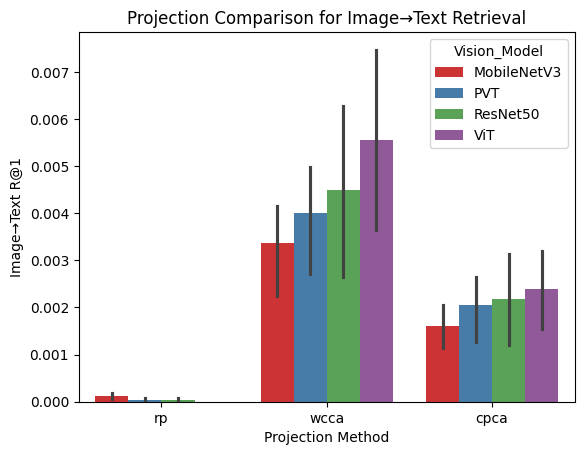

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x="Projection",
    y="i2t_R@1",
    hue="Vision_Model"
)
sns.set_palette("Set1")

plt.xlabel("Projection Method")
plt.ylabel("Image→Text R@1")
plt.title("Projection Comparison for Image→Text Retrieval")
plt.show()


In [ ]:
# Clean Projection names
df["Projection"] = df["Projection"].str.strip().str.lower()

df_eff = df[df["Projection"] != "RP"].copy()
df_eff = df_eff.sort_values("Efficiency_i2t_latency")

df_eff.head()


,Vision_Model,Text_Model,Projection,Fusion,i2t_R@1,i2t_R@5,i2t_R@10,i2t_MedR,i2t_MeanR,t2i_R@1,...,Efficiency_m2t_latency,Efficiency_m2t_per_sample,Efficiency_m2t_throughput,Efficiency_m2t_gpu_mem,Efficiency_m2i_latency,Efficiency_m2i_per_sample,Efficiency_m2i_throughput,Efficiency_m2i_gpu_mem,Global_Score,Efficiency_Score
23,MobileNetV3,GPT2,wcca,Multiplication,0.001112,0.003708,0.009146,51.0,49.982697,0.000173,...,4.707205,0.000116,8594.271172,0.0,1.046233,0.000026,38667.307790,0.0,0.000643,0.000407
21,MobileNetV3,GPT2,wcca,Addition,0.001112,0.003708,0.009146,51.0,49.982697,0.000173,...,4.844191,0.000120,8351.239696,0.0,0.955418,0.000024,42342.724759,0.0,0.000643,0.000407
22,MobileNetV3,GPT2,wcca,Gated,0.001112,0.003708,0.009146,51.0,49.982697,0.000173,...,4.967358,0.000123,8144.169065,0.0,0.978833,0.000024,41329.826136,0.0,0.000643,0.000407
104,ViT,GPT2,wcca,Multiplication,0.001730,0.010258,0.018663,51.0,48.817699,0.000099,...,4.797616,0.000119,8432.312956,0.0,1.088219,0.000027,37175.415827,0.0,0.000915,0.000501
102,ViT,GPT2,wcca,Addition,0.001730,0.010258,0.018663,51.0,48.817699,0.000099,...,4.815633,0.000119,8400.764075,0.0,1.100729,0.000027,36752.907986,0.0,0.000915,0.000501


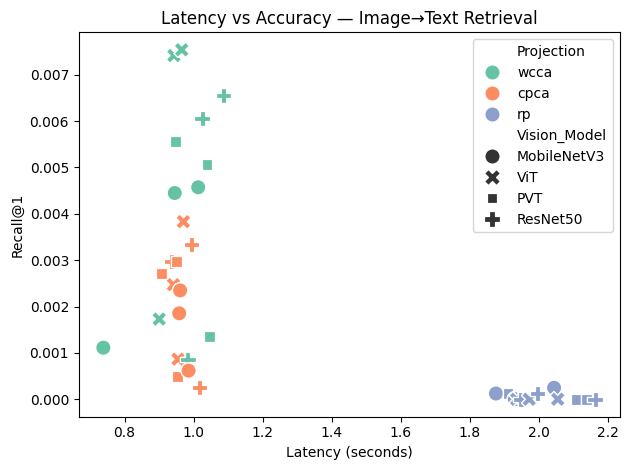

In [ ]:
sns.set_palette("Set3")
sns.scatterplot(
    data=df_eff,
    x="Efficiency_i2t_latency",
    y="i2t_R@1",
    hue="Projection",
    style="Vision_Model",
    s=120,
    palette="Set2"
)
plt.title("Latency vs Accuracy — Image→Text Retrieval")
plt.xlabel("Latency (seconds)")
plt.ylabel("Recall@1")
plt.tight_layout()
plt.show()


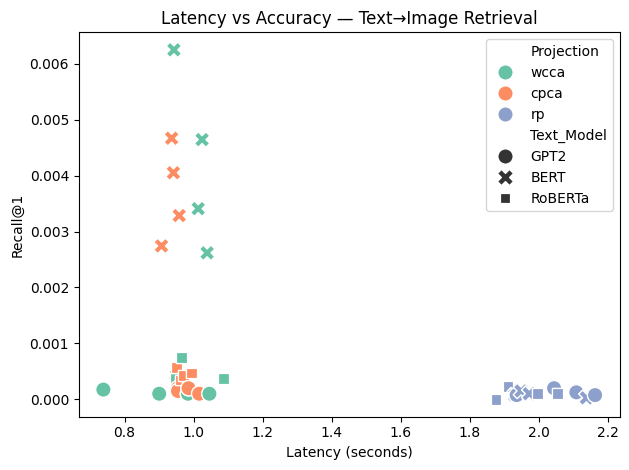

In [ ]:
sns.set_palette("Set3")
sns.scatterplot(
    data=df_eff,
    x="Efficiency_i2t_latency",
    y="t2i_R@1",
    hue="Projection",
    style="Text_Model",
    s=120,
    palette="Set2"
)
plt.title("Latency vs Accuracy — Text→Image Retrieval")
plt.xlabel("Latency (seconds)")
plt.ylabel("Recall@1")
plt.tight_layout()
plt.show()


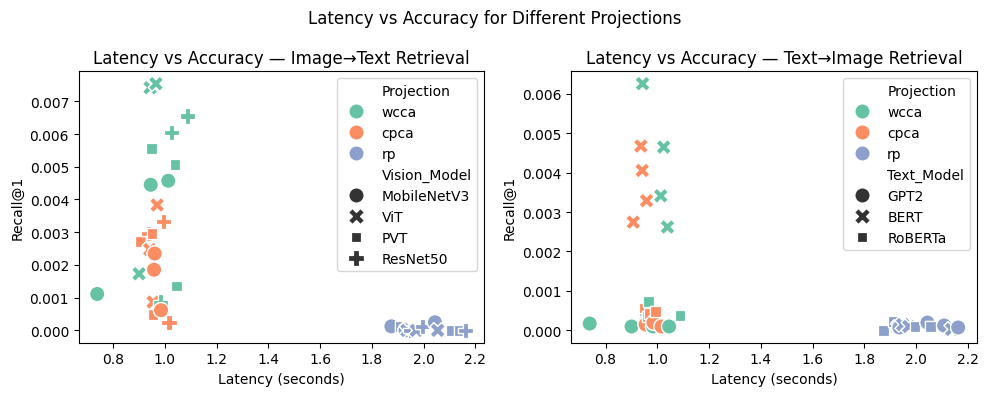

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Latency vs Accuracy for Different Projections")
sns.set_palette("Set2")
sns.scatterplot(
    data=df_eff,
    x="Efficiency_i2t_latency",
    y="i2t_R@1",
    hue="Projection",
    style="Vision_Model",
    s=120,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Latency vs Accuracy — Image→Text Retrieval")
axes[0].set_xlabel("Latency (seconds)")
axes[0].set_ylabel("Recall@1") 
sns.scatterplot(
    data=df_eff,
    x="Efficiency_i2t_latency",
    y="t2i_R@1",
    hue="Projection",
    style="Text_Model",
    s=120,
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Latency vs Accuracy — Text→Image Retrieval")
axes[1].set_xlabel("Latency (seconds)")
axes[1].set_ylabel("Recall@1")
plt.tight_layout()
plt.show()

In [ ]:
Efficiency_cols = [
    "Vision_Model", "Text_Model", "Projection",
    "Efficiency_i2t_latency", "Efficiency_t2i_latency",
    "Efficiency_m2t_latency", "Efficiency_m2i_latency",
    "Efficiency_i2t_throughput", "Efficiency_t2i_throughput"
]

df_eff = df[Efficiency_cols].sort_values("Efficiency_i2t_latency")
df_eff.head()


,Vision_Model,Text_Model,Projection,Efficiency_i2t_latency,Efficiency_t2i_latency,Efficiency_m2t_latency,Efficiency_m2i_latency,Efficiency_i2t_throughput,Efficiency_t2i_throughput
23,MobileNetV3,GPT2,wcca,0.738793,0.841759,4.707205,1.046233,10951.641277,48060.065228
21,MobileNetV3,GPT2,wcca,0.738793,0.841759,4.844191,0.955418,10951.641277,48060.065228
22,MobileNetV3,GPT2,wcca,0.738793,0.841759,4.967358,0.978833,10951.641277,48060.065228
104,ViT,GPT2,wcca,0.900476,0.924305,4.797616,1.088219,8985.245634,43768.028862
102,ViT,GPT2,wcca,0.900476,0.924305,4.815633,1.100729,8985.245634,43768.028862


In [ ]:
df.groupby(["Vision_Model", "Text_Model"]).apply(
    lambda g: g.loc[g["t2i_R@1"].idxmax()][["Projection", "t2i_R@1"]]
)


Projection   t2i_R@1
Vision_Model Text_Model                     
MobileNetV3  BERT             wcca  0.003411
             GPT2               rp  0.000198
             RoBERTa          wcca  0.000420
PVT          BERT             cpca  0.002744
             GPT2             cpca  0.000198
             RoBERTa          cpca  0.000569
ResNet50     BERT             cpca  0.004672
             GPT2             wcca  0.000099
             RoBERTa          cpca  0.000470
ViT          BERT             wcca  0.006254
             GPT2             cpca  0.000148
             RoBERTa          wcca  0.000742

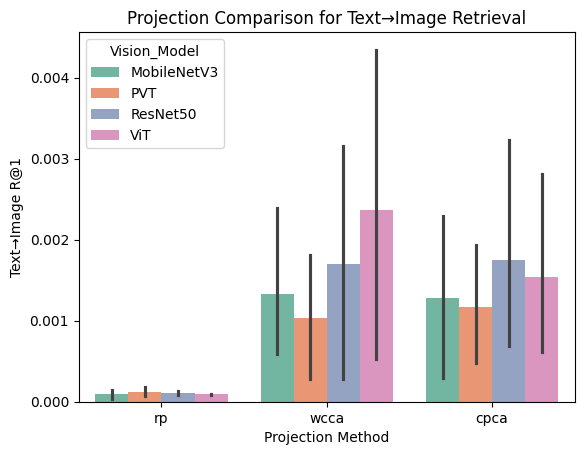

In [ ]:
sns.barplot(
    data=df,
    x="Projection",
    y="t2i_R@1",
    hue="Vision_Model"
)
sns.set_palette("Set1")

plt.xlabel("Projection Method")
plt.ylabel("Text→Image R@1")
plt.title("Projection Comparison for Text→Image Retrieval")
plt.show()


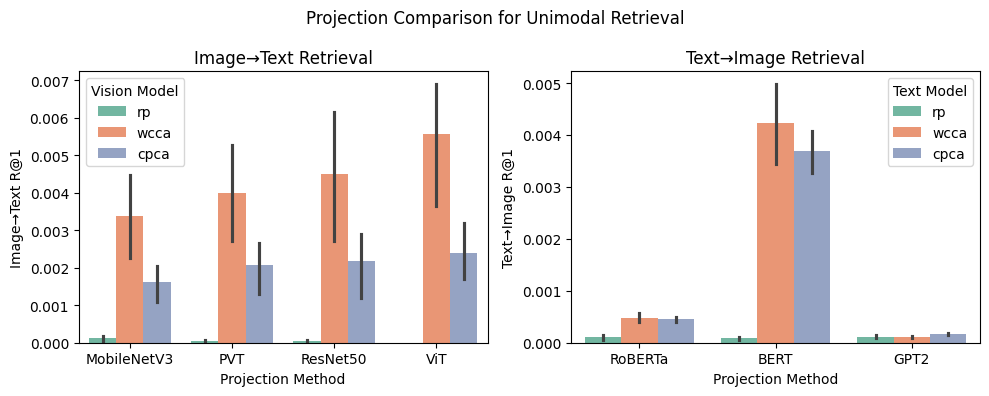

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.set_palette("Set2")
sns.barplot(data=df, x="Text_Model", y="t2i_R@1", hue="Projection", ax=axes[1])
sns.barplot(data=df, x="Vision_Model", y="i2t_R@1", hue="Projection", ax=axes[0])
axes[0].set_xlabel("Projection Method")
axes[0].set_ylabel("Image→Text R@1")
axes[0].set_title("Image→Text Retrieval")
axes[0].legend(title="Vision Model")
axes[1].set_xlabel("Projection Method")
axes[1].set_ylabel("Text→Image R@1")
axes[1].legend(title="Text Model")
axes[1].set_title("Text→Image Retrieval")
fig.suptitle("Projection Comparison for Unimodal Retrieval")
plt.tight_layout()


Text(0.5, 1.0, 'Image→Text Recall@1 by Projection and Vision Model')

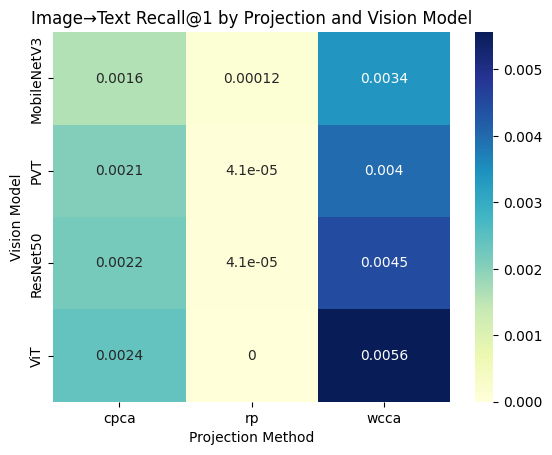

In [ ]:
sns.heatmap(df.pivot_table(index="Vision_Model", columns="Projection", values="i2t_R@1"), annot=True, cmap="YlGnBu")
plt.xlabel("Projection Method")
plt.ylabel("Vision Model")
plt.title("Image→Text Recall@1 by Projection and Vision Model")


Text(0.5, 1.0, 'Text→Image Recall@1 by Projection and Text Model')

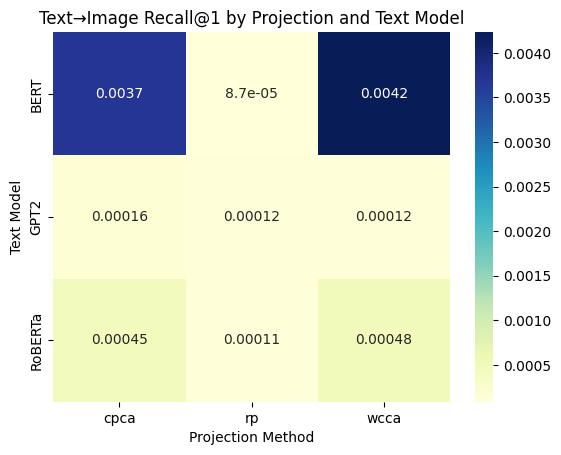

In [ ]:
sns.heatmap(df.pivot_table(index="Text_Model", columns="Projection", values="t2i_R@1"), annot=True, cmap="YlGnBu")
plt.xlabel("Projection Method")
plt.ylabel("Text Model")
plt.title("Text→Image Recall@1 by Projection and Text Model")


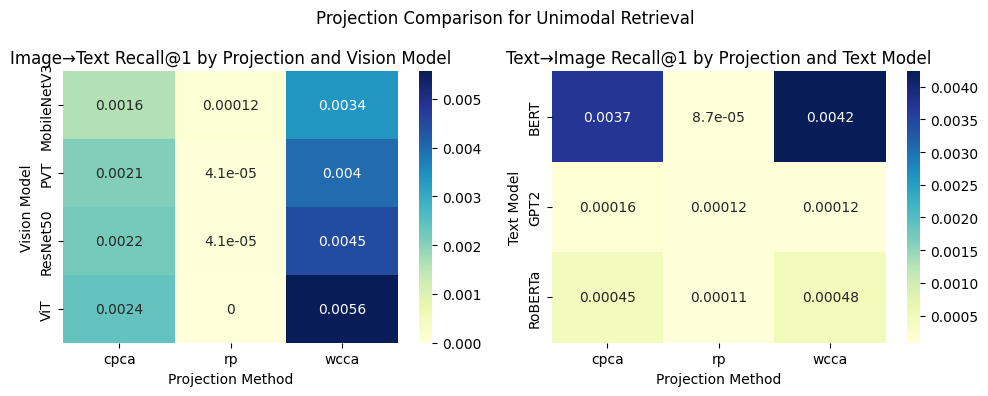

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(df.pivot_table(index="Vision_Model", columns="Projection", values="i2t_R@1"), annot=True, cmap="YlGnBu", ax=axes[0])
axes[0].set_xlabel("Projection Method")
axes[0].set_ylabel("Vision Model")
axes[0].set_title("Image→Text Recall@1 by Projection and Vision Model")
sns.heatmap(df.pivot_table(index="Text_Model", columns="Projection", values="t2i_R@1"), annot=True, cmap="YlGnBu", ax=axes[1])
axes[1].set_xlabel("Projection Method")
axes[1].set_ylabel("Text Model")
axes[1].set_title("Text→Image Recall@1 by Projection and Text Model")
fig.suptitle("Projection Comparison for Unimodal Retrieval")
plt.tight_layout()


In [ ]:
df.groupby(["Vision_Model", "Text_Model"]).apply(
    lambda g: g.loc[g["m2t_R@1"].idxmax()][["Projection", "m2t_R@1"]]
)


Projection   m2t_R@1
Vision_Model Text_Model                     
MobileNetV3  BERT               rp  0.000025
             GPT2             cpca  0.000025
             RoBERTa            rp  0.000025
PVT          BERT             wcca  0.000025
             GPT2             wcca  0.000025
             RoBERTa            rp  0.000000
ResNet50     BERT               rp  0.000000
             GPT2               rp  0.000025
             RoBERTa          wcca  0.000025
ViT          BERT             cpca  0.000025
             GPT2             wcca  0.000025
             RoBERTa            rp  0.000000

In [ ]:
df.groupby(["Vision_Model", "Text_Model"]).apply(
    lambda g: g.loc[g["m2i_R@1"].idxmax()][["Projection", "m2i_R@1"]]
)


Projection   m2i_R@1
Vision_Model Text_Model                     
MobileNetV3  BERT               rp  0.000049
             GPT2             wcca  0.000099
             RoBERTa            rp  0.000099
PVT          BERT               rp  0.000025
             GPT2               rp  0.000049
             RoBERTa          wcca  0.000049
ResNet50     BERT             cpca  0.000074
             GPT2             wcca  0.000049
             RoBERTa            rp  0.000049
ViT          BERT             cpca  0.000074
             GPT2               rp  0.000025
             RoBERTa            rp  0.000074

In [ ]:
best_i2t = df.groupby(["Vision_Model", "Text_Model"]).apply(
    lambda g: g.loc[g["i2t_R@1"].idxmax()][["Projection", "i2t_R@1"]]
)

best_t2i = df.groupby(["Vision_Model", "Text_Model"]).apply(
    lambda g: g.loc[g["t2i_R@1"].idxmax()][["Projection", "t2i_R@1"]]
)

best_m2t = df.groupby(["Vision_Model", "Text_Model"]).apply(
    lambda g: g.loc[g["m2t_R@1"].idxmax()][["Projection", "m2t_R@1"]]
)

best_m2i = df.groupby(["Vision_Model", "Text_Model"]).apply(
    lambda g: g.loc[g["m2i_R@1"].idxmax()][["Projection", "m2i_R@1"]]
)

summary = pd.concat(
    [best_i2t, best_t2i, best_m2t, best_m2i],
    axis=1
)

summary.columns = [
    "best_i2t_proj", "i2t_R@1",
    "best_t2i_proj", "t2i_R@1",
    "best_m2t_proj", "m2t_R@1",
    "best_m2i_proj", "m2i_R@1"
]

summary


best_i2t_proj   i2t_R@1 best_t2i_proj   t2i_R@1  \
Vision_Model Text_Model                                                   
MobileNetV3  BERT                wcca  0.004573          wcca  0.003411   
             GPT2                wcca  0.001112            rp  0.000198   
             RoBERTa             wcca  0.004449          wcca  0.000420   
PVT          BERT                wcca  0.005067          cpca  0.002744   
             GPT2                wcca  0.001360          cpca  0.000198   
             RoBERTa             wcca  0.005562          cpca  0.000569   
ResNet50     BERT                wcca  0.006056          cpca  0.004672   
             GPT2                wcca  0.000865          wcca  0.000099   
             RoBERTa             wcca  0.006550          cpca  0.000470   
ViT          BERT                wcca  0.007416          wcca  0.006254   
             GPT2                wcca  0.001730          cpca  0.000148   
             RoBERTa             wcca  0.007539          wcca  0.000742   

                        best_m2t_proj   m2t_R@1 best_m2i_proj   m2i_R@1  
Vision_Model Text_Model                                                  
MobileNetV3  BERT                  rp  0.000025            rp  0.000049  
             GPT2                cpca  0.000025          wcca  0.000099  
             RoBERTa               rp  0.000025            rp  0.000099  
PVT          BERT                wcca  0.000025            rp  0.000025  
             GPT2                wcca  0.000025            rp  0.000049  
             RoBERTa               rp  0.000000          wcca  0.000049  
ResNet50     BERT                  rp  0.000000          cpca  0.000074  
             GPT2                  rp  0.000025          wcca  0.000049  
             RoBERTa             wcca  0.000025            rp  0.000049  
ViT          BERT                cpca  0.000025          cpca  0.000074  
             GPT2                wcca  0.000025            rp  0.000025  
             RoBERTa               rp  0.000000            rp  0.000074

In [ ]:
df["alignment_score"] = (df["i2t_R@1"] + df["t2i_R@1"]) / 2
rank_alignment = df.sort_values("alignment_score", ascending=False)[
    ["Vision_Model", "Text_Model", "Projection", "alignment_score"]
]
rank_alignment

,Vision_Model,Text_Model,Projection,alignment_score
93,ViT,BERT,wcca,0.006835
94,ViT,BERT,wcca,0.006835
95,ViT,BERT,wcca,0.006835
67,ResNet50,BERT,wcca,0.005352
66,ResNet50,BERT,wcca,0.005352
...,...,...,...,...
9,MobileNetV3,BERT,rp,0.000037
11,MobileNetV3,BERT,rp,0.000037
38,PVT,BERT,rp,0.000012
36,PVT,BERT,rp,0.000012


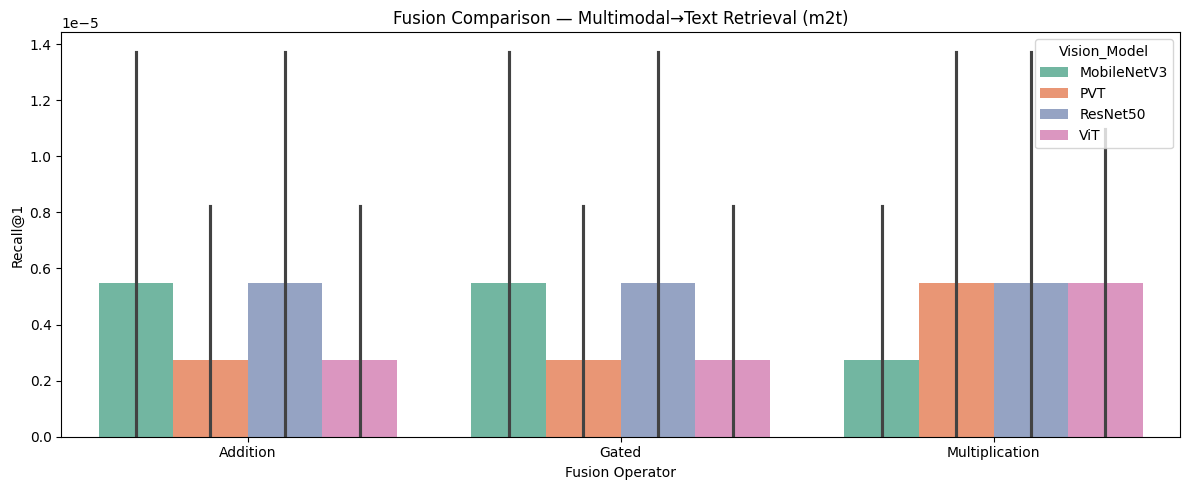

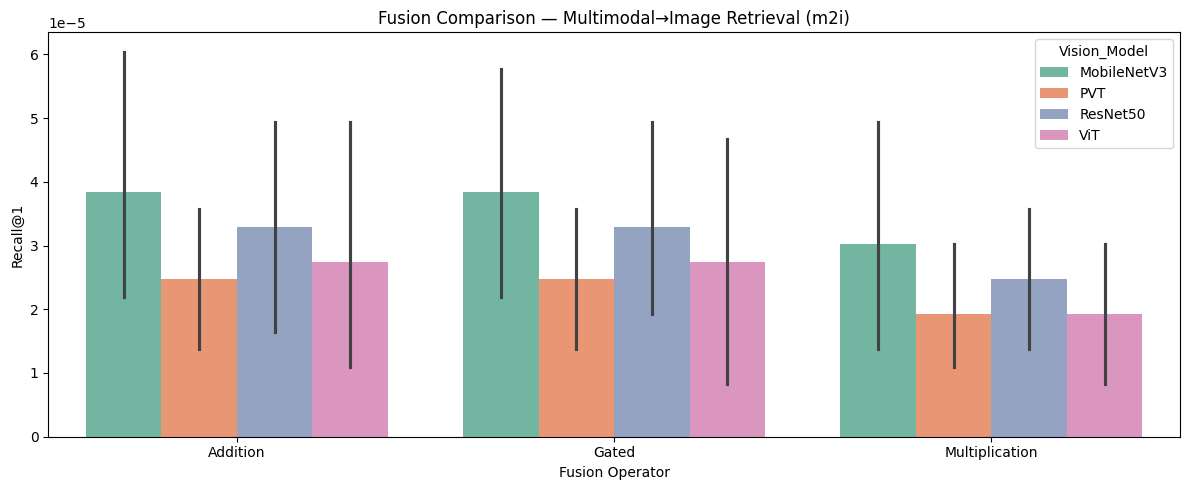

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_Fusion = df.copy()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=df_Fusion,
    x="Fusion",
    y="m2t_R@1",
    hue="Vision_Model",
    palette="Set2"
)
plt.title("Fusion Comparison — Multimodal→Text Retrieval (m2t)")
plt.xlabel("Fusion Operator")
plt.ylabel("Recall@1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=df_Fusion,
    x="Fusion",
    y="m2i_R@1",
    hue="Vision_Model",
    palette="Set2"
)
plt.title("Fusion Comparison — Multimodal→Image Retrieval (m2i)")
plt.xlabel("Fusion Operator")
plt.ylabel("Recall@1")
plt.tight_layout()
plt.show()


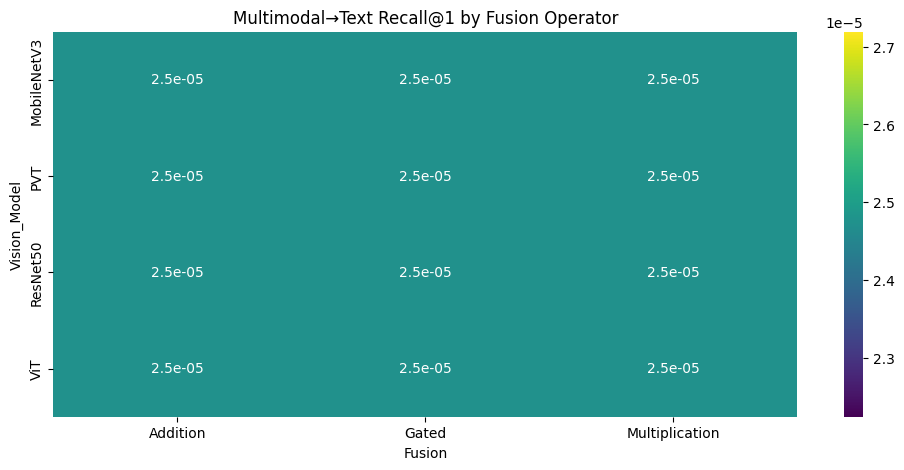

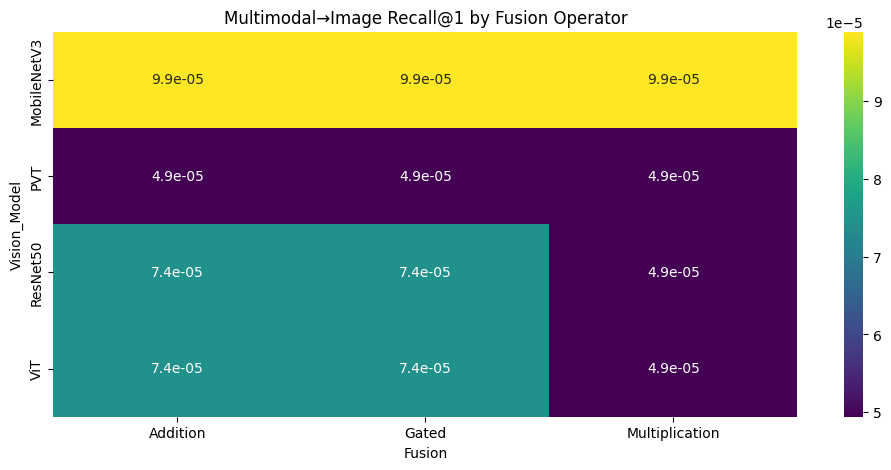

In [ ]:
import numpy as np

pivot_m2t = df_Fusion.pivot_table(
    index="Vision_Model",
    columns="Fusion",
    values="m2t_R@1",
    aggfunc="max"
)

pivot_m2i = df_Fusion.pivot_table(
    index="Vision_Model",
    columns="Fusion",
    values="m2i_R@1",
    aggfunc="max"
)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_m2t, annot=True, cmap="viridis")
plt.title("Multimodal→Text Recall@1 by Fusion Operator")
plt.show()

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_m2i, annot=True, cmap="viridis")
plt.title("Multimodal→Image Recall@1 by Fusion Operator")
plt.show()


In [ ]:
df_Fusion["Fusion_score"] = (df_Fusion["m2t_R@1"] + df_Fusion["m2i_R@1"]) / 2

Fusion_rank = df_Fusion.sort_values("Fusion_score", ascending=False)[
    ["Vision_Model", "Text_Model", "Projection", "Fusion", "Fusion_score"]
]

Fusion_rank.head(10)


,Vision_Model,Text_Model,Projection,Fusion,fusion_score
23,MobileNetV3,GPT2,wcca,Multiplication,0.000049
1,MobileNetV3,RoBERTa,rp,Gated,0.000049
0,MobileNetV3,RoBERTa,rp,Addition,0.000049
69,ResNet50,BERT,cpca,Addition,0.000037
82,ViT,RoBERTa,rp,Gated,0.000037
81,ViT,RoBERTa,rp,Addition,0.000037
96,ViT,BERT,cpca,Addition,0.000037
97,ViT,BERT,cpca,Gated,0.000037
70,ResNet50,BERT,cpca,Gated,0.000037
98,ViT,BERT,cpca,Multiplication,0.000037


In [ ]:
df_Efficiency_fusion = df_fusion[df_fusion["Projection"] != "rp"].copy()

Efficiency_cols = [
    "Vision_Model", "Text_Model", "Projection", "Fusion",
    "Efficiency_m2t_latency", "Efficiency_m2i_latency",
    "Efficiency_m2t_throughput", "Efficiency_m2i_throughput"
]

df_Efficiency_fusion_table = df_Efficiency_fusion[Efficiency_cols].sort_values("Efficiency_m2t_latency")
df_Efficiency_fusion_table.head()


,Vision_Model,Text_Model,Projection,Fusion,Efficiency_m2t_latency,Efficiency_m2i_latency,Efficiency_m2t_throughput,Efficiency_m2i_throughput
44,PVT,BERT,cpca,Multiplication,4.139716,0.803471,9772.408708,50350.322985
43,PVT,BERT,cpca,Gated,4.613252,0.878623,8769.302780,46043.658273
34,PVT,RoBERTa,cpca,Gated,4.683009,1.064474,8638.675919,38004.694021
23,MobileNetV3,GPT2,wcca,Multiplication,4.707205,1.046233,8594.271172,38667.307790
53,PVT,GPT2,cpca,Multiplication,4.723096,1.087049,8565.356130,37215.430192


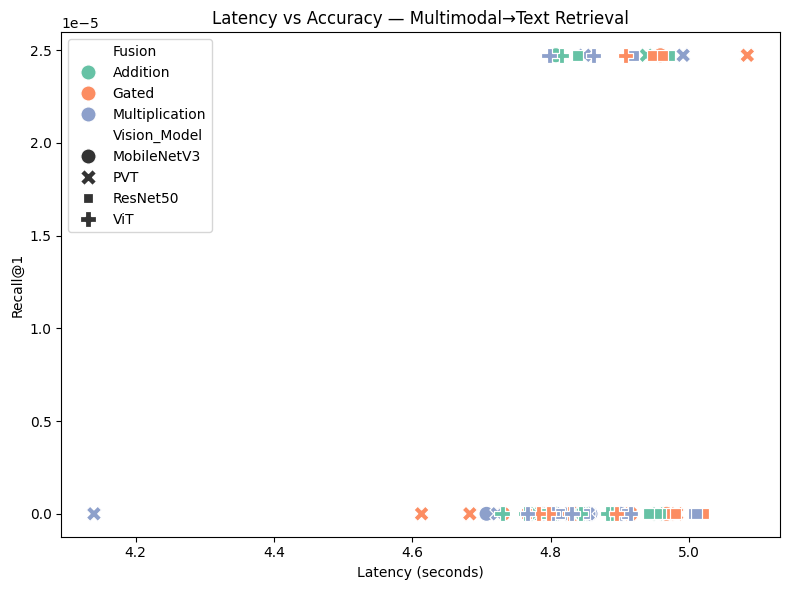

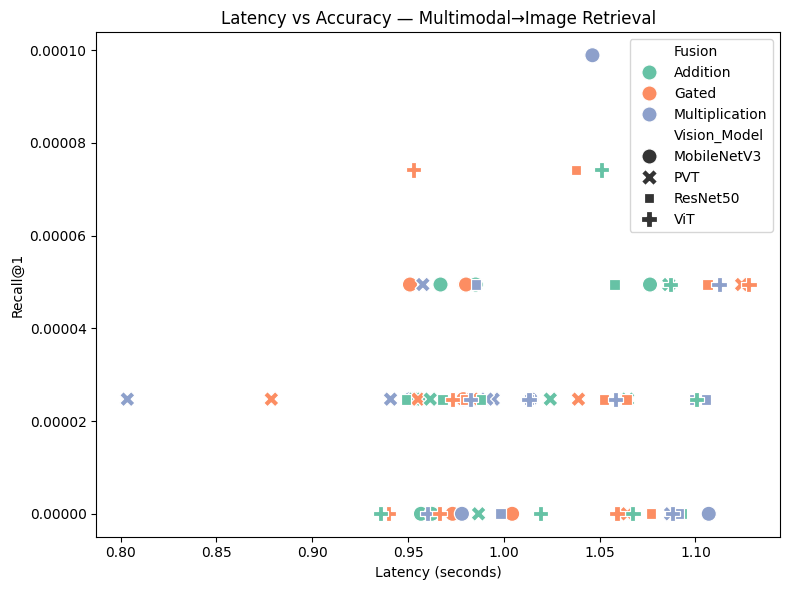

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_Efficiency_fusion,
    x="Efficiency_m2t_latency",
    y="m2t_R@1",
    hue="Fusion",
    style="Vision_Model",
    s=120,
    palette="Set2"
)
plt.title("Latency vs Accuracy — Multimodal→Text Retrieval")
plt.xlabel("Latency (seconds)")
plt.ylabel("Recall@1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_Efficiency_fusion,
    x="Efficiency_m2i_latency",
    y="m2i_R@1",
    hue="Fusion",
    style="Vision_Model",
    s=120,
    palette="Set2"
)
plt.title("Latency vs Accuracy — Multimodal→Image Retrieval")
plt.xlabel("Latency (seconds)")
plt.ylabel("Recall@1")
plt.tight_layout()
plt.show()


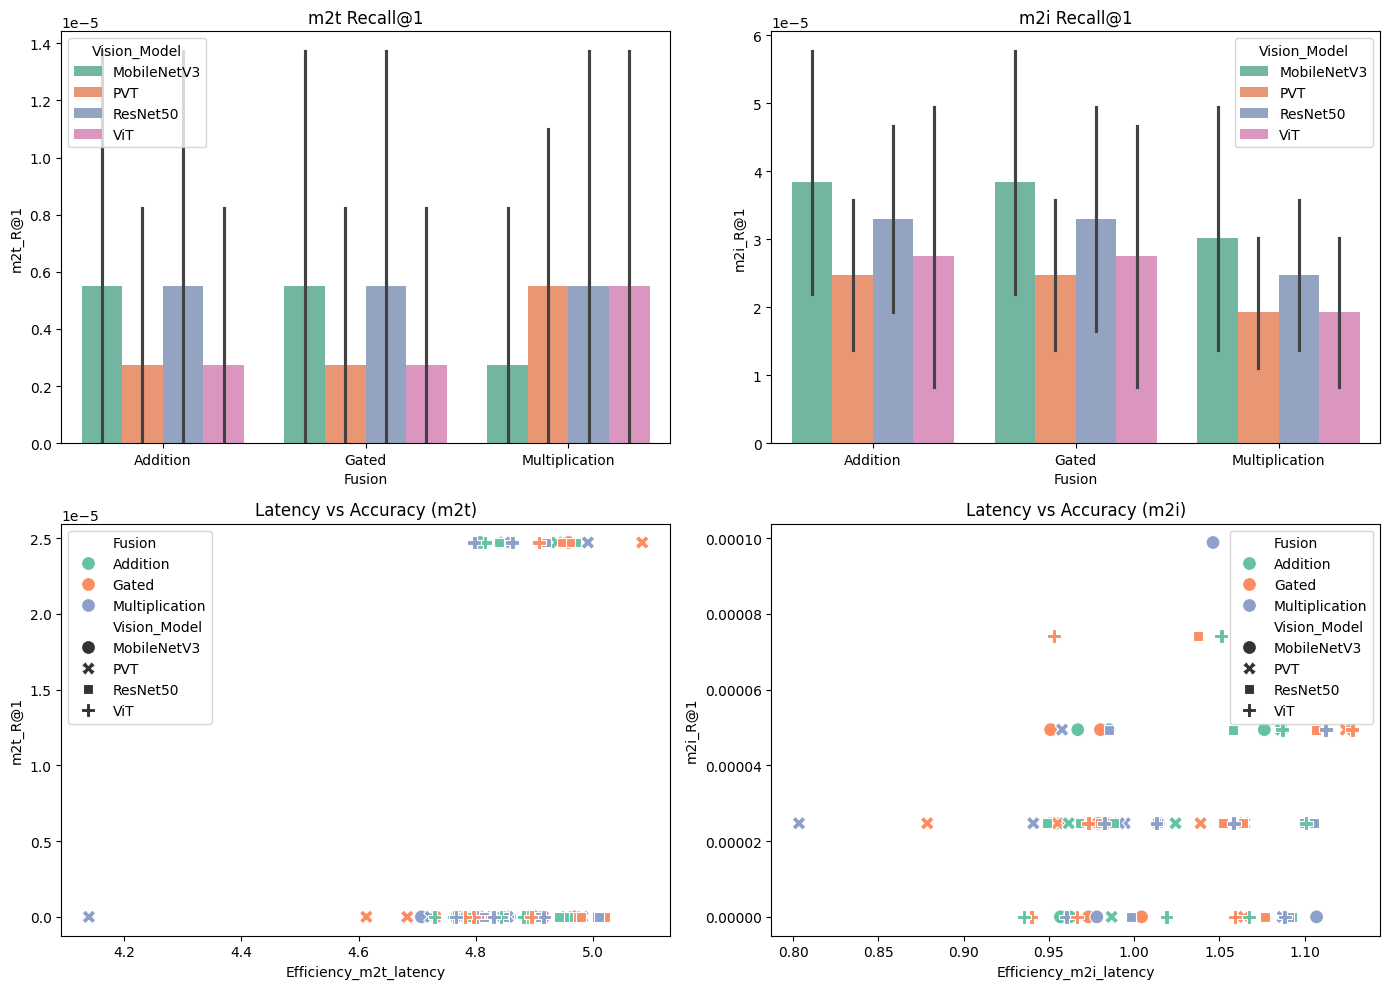

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=df_fusion, x="Fusion", y="m2t_R@1", hue="Vision_Model", ax=axes[0,0])
axes[0,0].set_title("m2t Recall@1")

sns.barplot(data=df_fusion, x="Fusion", y="m2i_R@1", hue="Vision_Model", ax=axes[0,1])
axes[0,1].set_title("m2i Recall@1")

sns.scatterplot(data=df_Efficiency_fusion, x="Efficiency_m2t_latency", y="m2t_R@1",
                hue="Fusion", style="Vision_Model", s=100, ax=axes[1,0])
axes[1,0].set_title("Latency vs Accuracy (m2t)")

sns.scatterplot(data=df_Efficiency_fusion, x="Efficiency_m2i_latency", y="m2i_R@1",
                hue="Fusion", style="Vision_Model", s=100, ax=axes[1,1])
axes[1,1].set_title("Latency vs Accuracy (m2i)")

plt.tight_layout()
plt.show()


# Fusion Analysis

In [ ]:
df.groupby("Fusion")[["m2t_R@1", "m2i_R@1"]].mean()


,m2t_R@1,m2i_R@1
Fusion,,
Addition,0.000004,0.000031
Gated,0.000004,0.000031
Multiplication,0.000005,0.000023


In [ ]:
df.groupby(["Vision_Model", "Text_Model"])[["i2t_R@1", "t2i_R@1"]].mean()


i2t_R@1   t2i_R@1
Vision_Model Text_Model                    
MobileNetV3  BERT        0.002142  0.002258
             GPT2        0.000659  0.000190
             RoBERTa     0.002307  0.000255
PVT          BERT        0.002595  0.001796
             GPT2        0.000618  0.000140
             RoBERTa     0.002884  0.000387
ResNet50     BERT        0.003007  0.003156
             GPT2        0.000371  0.000091
             RoBERTa     0.003337  0.000313
ViT          BERT        0.003296  0.003469
             GPT2        0.000865  0.000107
             RoBERTa     0.003790  0.000420

In [ ]:
df.groupby(["Vision_Model", "Text_Model", "Fusion"])[["m2t_R@1", "m2i_R@1"]].mean()


m2t_R@1   m2i_R@1
Vision_Model Text_Model Fusion                            
MobileNetV3  BERT       Addition        0.000008  0.000049
                        Gated           0.000008  0.000049
                        Multiplication  0.000000  0.000016
             GPT2       Addition        0.000008  0.000016
                        Gated           0.000008  0.000016
                        Multiplication  0.000000  0.000041
             RoBERTa    Addition        0.000000  0.000049
                        Gated           0.000000  0.000049
                        Multiplication  0.000008  0.000033
PVT          BERT       Addition        0.000000  0.000025
                        Gated           0.000000  0.000025
                        Multiplication  0.000008  0.000025
             GPT2       Addition        0.000008  0.000041
                        Gated           0.000008  0.000041
                        Multiplication  0.000008  0.000008
             RoBERTa    Addition        0.000000  0.000008
                        Gated           0.000000  0.000008
                        Multiplication  0.000000  0.000025
ResNet50     BERT       Addition        0.000000  0.000049
                        Gated           0.000000  0.000049
                        Multiplication  0.000000  0.000025
             GPT2       Addition        0.000008  0.000025
                        Gated           0.000008  0.000025
                        Multiplication  0.000016  0.000025
             RoBERTa    Addition        0.000008  0.000025
                        Gated           0.000008  0.000025
                        Multiplication  0.000000  0.000025
ViT          BERT       Addition        0.000000  0.000025
                        Gated           0.000000  0.000025
                        Multiplication  0.000008  0.000025
             GPT2       Addition        0.000008  0.000016
                        Gated           0.000008  0.000016
                        Multiplication  0.000008  0.000016
             RoBERTa    Addition        0.000000  0.000041
                        Gated           0.000000  0.000041
                        Multiplication  0.000000  0.000016

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def show_image_with_captions(img_idx):
    img_name = images[img_idx]
    img_path = os.path.join(IMAGE_DIR, img_name)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {img_idx}: {img_name}")
    plt.show()

    print("\nGround truth captions:")
    for i in range(5):
        print(f"- {captions[img_idx*5 + i]}")


In [ ]:
def show_top5_captions(topk, title):
    print(f"\n🔵 {title} — Top‑5 captions:")
    for rank, cap_idx in enumerate(topk[:5]):
        print(f"{rank+1}. {captions[cap_idx]}")


In [ ]:
def show_top5_images(topk, title):
    print(f"\n🟣 {title} — Top‑5 images:")
    for rank, img_idx in enumerate(topk[:5]):
        print(f"{rank+1}. Image {img_idx} — {images[img_idx]}")
        img_name = images[img_idx]
        img_path = os.path.join(IMAGE_DIR, img_name)

        img = Image.open(img_path)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {img_idx}: {img_name}")
        plt.show()


In [ ]:
def visualize_example(img_idx, v, t, proj, fusion):
    print("====================================")
    print(f"Example for {v} × {t} — {proj} — fusion={fusion}")
    print("====================================")

    # 1) Show image + captions
    show_image_with_captions(img_idx)

    # 2) Load top‑50 arrays
    i2t = np.load(f"UP_retrieval_results_all/{v}_{t}_{proj}_i2t_top50.npy")
    t2i = np.load(f"UP_retrieval_results_all/{v}_{t}_{proj}_t2i_top50.npy")
    m2t = np.load(f"UP_retrieval_results_all/{v}_{t}_{proj}_{fusion}_m2t_top50.npy")
    m2i = np.load(f"UP_retrieval_results_all/{v}_{t}_{proj}_{fusion}_m2i_top50.npy")

    # 3) Show top‑5 for each retrieval type
    show_top5_captions(i2t[img_idx], "i2t (Image → Text)")
    show_top5_images(t2i[img_idx*5], "t2i (Text → Image)")
    show_top5_captions(m2t[img_idx], "m2t (Fusion → Text)")
    show_top5_images(m2i[img_idx], "m2i (Fusion → Image)")


Example for MobileNetV3 × RoBERTa — WCCA — fusion=Multiplication


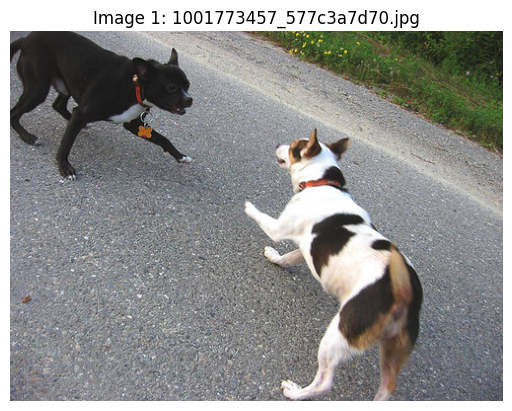


Ground truth captions:
- A black dog and a spotted dog are fighting
- A black dog and a tri-colored dog playing with each other on the road .
- A black dog and a white dog with brown spots are staring at each other in the street .
- Two dogs of different breeds looking at each other on the road .
- Two dogs on pavement moving toward each other .

🔵 i2t (Image → Text) — Top‑5 captions:
1. Brown and white dog with brown and black dog on gray sheet .
2. A black and tan dog and a black and white dog are playing ball in the grass .
3. A black and white dog chases a bigger dog across the grass .
4. The yellow and black cat and the brown and black dog are fighting .
5. A black dog is chasing a brown and white dog across the grass .

🟣 t2i (Text → Image) — Top‑5 images:
1. Image 5865 — 3482062809_3b694322c4.jpg


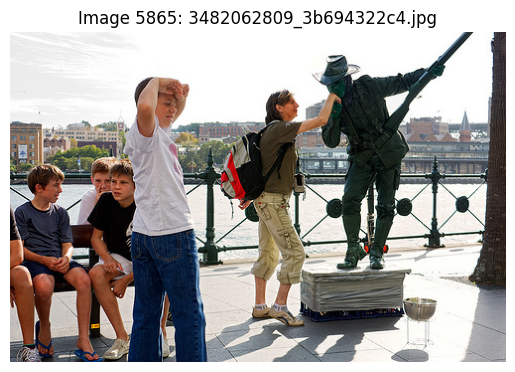

2. Image 5682 — 3443853670_6c79fcfcb2.jpg


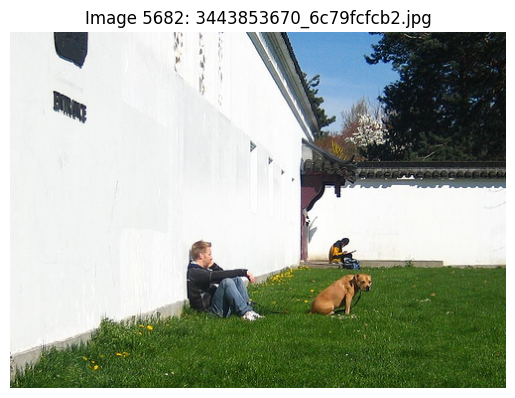

3. Image 6617 — 3632258003_6a0a69bf3a.jpg


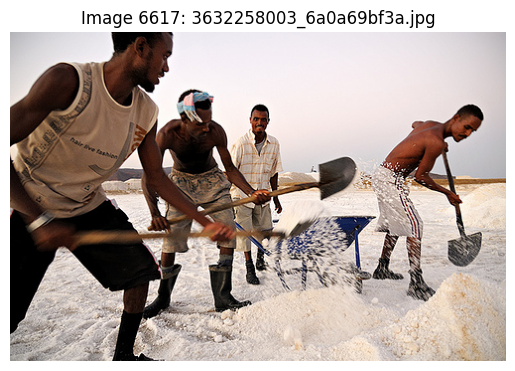

4. Image 6209 — 3547647914_4dd56a8c1b.jpg


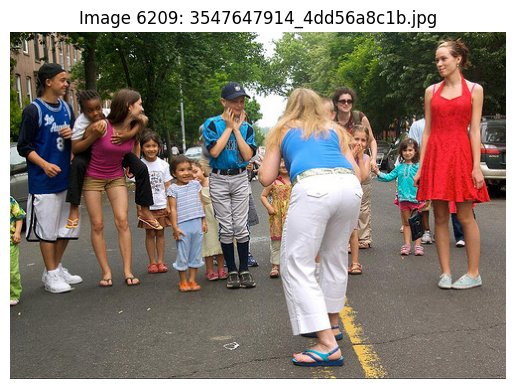

5. Image 4620 — 3229730008_63f8ca2de2.jpg


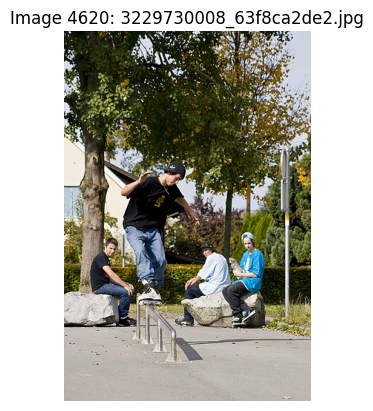


🔵 m2t (Fusion → Text) — Top‑5 captions:
1. A woman laughing and a man using a noise maker .
2. The girl is running through a park near a wooden park bench .
3. A group of children watching a man do a bicycle stunt .
4. A group of children outside a building includes a boy jumping in the grass .
5. A man doing a jumping bike trick surrounded by trees .

🟣 m2i (Fusion → Image) — Top‑5 images:
1. Image 5207 — 3350671534_2a5d45a961.jpg


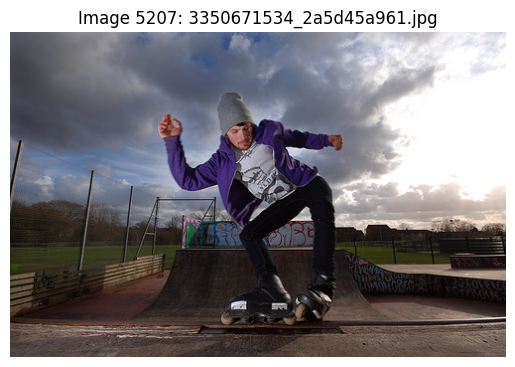

2. Image 171 — 1198194316_543cc7b945.jpg


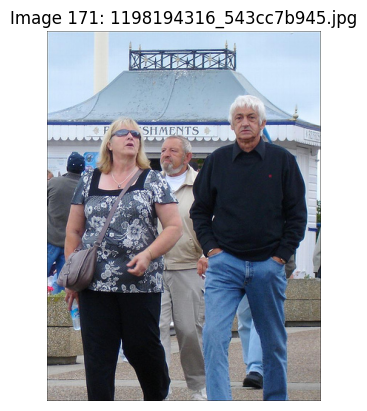

3. Image 6842 — 3679502342_7fe6ef8a36.jpg


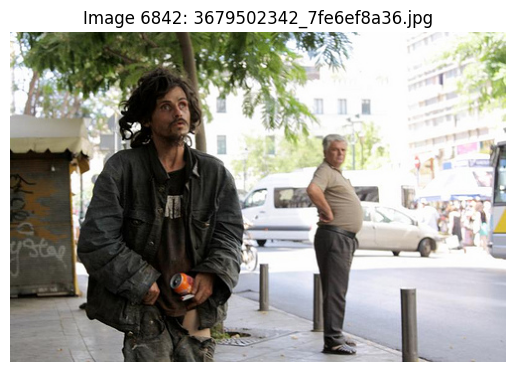

4. Image 6209 — 3547647914_4dd56a8c1b.jpg


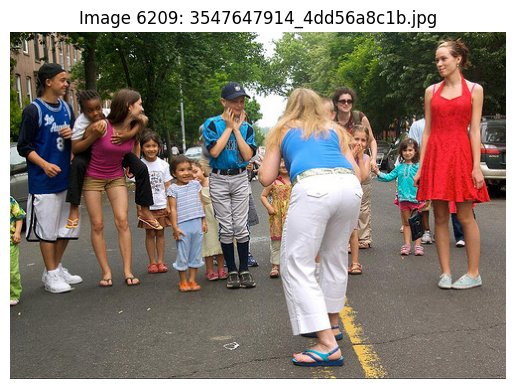

5. Image 6851 — 3681575323_433d007650.jpg


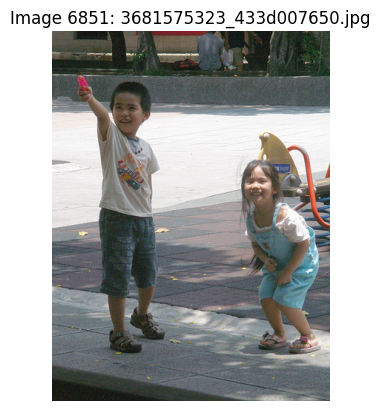

In [ ]:
visualize_example(
    img_idx=1,          # n'importe quelle image
    v="MobileNetV3",
    t="RoBERTa",
    proj="WCCA",
    fusion="Multiplication"
)
